**Importing Libraries**

In [ ]:
from preprocess import get_data_generator_rgb
from keras._tf_keras.keras.applications import ResNet50
from keras._tf_keras.keras.models import load_model, Model
from keras._tf_keras.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input
from keras._tf_keras.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from keras._tf_keras.keras.optimizers import Adam
import matplotlib.pyplot as plt
import json
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import seaborn as sns
from tf_keras_vis.gradcam import Gradcam
from tf_keras_vis.utils.scores import CategoricalScore
import cv2
import os
from random import choice
import pandas as pd

**Load and Prepare Dataset**

In [4]:
train_dir = 'fer2013/train'
test_dir = 'fer2013/test'
img_size = (48, 48)
batch_size = 32
num_classes = 7
# Load data using your custom preprocess
train_gen, val_gen, test_gen = get_data_generator_rgb(train_dir, test_dir, img_size=img_size, batch_size=batch_size)

Found 22968 images belonging to 7 classes.
Found 5741 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


**Implementing ResNet50 Transfer Learning**

In [3]:
def build_resnet50_model(input_shape=(48, 48, 3), num_classes=7):
    input_layer = Input(shape=input_shape)

    # Load base ResNet50 model
    base_model = ResNet50(include_top=False, weights='imagenet', input_tensor=input_layer)

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.5)(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.3)(x)
    output = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=input_layer, outputs=output)
    return model

# Build the model
model = build_resnet50_model()
print(f"Total layers: {len(model.layers)}")
# Check how many are still trainable
trainable_count = sum([1 for layer in model.layers if layer.trainable])
print(f"Trainable layers: {trainable_count}")

model.summary()

Total layers: 180
Trainable layers: 180


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 48, 48, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 54, 54, 3) │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 24, 24,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 24, 24,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 24, 24,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 26, 26,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 12, 12,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 12, 12,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 12, 12,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 12, 12,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 12, 12,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 12, 12,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 12, 12,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 12, 12,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 12, 12,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 12, 12,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 12, 12,    │      1,024 │ conv2_block1_3_c

 Total params: 24,114,055 (91.99 MB)

 Trainable params: 24,060,935 (91.79 MB)

...

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 48, 48, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 54, 54, 3) │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 24, 24,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 24, 24,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 24, 24,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 26, 26,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 12, 12,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 12, 12,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 12, 12,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 12, 12,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 12, 12,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 12, 12,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 12, 12,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 12, 12,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 12, 12,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 12, 12,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 12, 12,    │      1,024 │ conv2_block1_3_c

 Total params: 24,114,055 (91.99 MB)

 Trainable params: 24,060,935 (91.79 MB)

 Non-trainable params: 53,120 (207.50 KB)

**Set Optimizers, Train Model and Plot Training Result**

Epoch 1/100
718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.2402 - loss: 2.3338
Epoch 1: val_loss improved from inf to 2.02018, saving model to drive/MyDrive/Colab Notebooks/resnet50_best.keras
718/718 ━━━━━━━━━━━━━━━━━━━━ 150s 128ms/step - accuracy: 0.2403 - loss: 2.3332 - val_accuracy: 0.1632 - val_loss: 2.0202 - learning_rate: 1.0000e-04
Epoch 2/100
718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.3998 - loss: 1.5559
Epoch 2: val_loss improved from 2.02018 to 1.41454, saving model to drive/MyDrive/Colab Notebooks/resnet50_best.keras
718/718 ━━━━━━━━━━━━━━━━━━━━ 64s 89ms/step - accuracy: 0.3999 - loss: 1.5558 - val_accuracy: 0.4618 - val_loss: 1.4145 - learning_rate: 1.0000e-04
Epoch 3/100
718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.4636 - loss: 1.4050
Epoch 3: val_loss improved from 1.41454 to 1.31768, saving model to drive/MyDrive/Colab Notebooks/resnet50_best.keras
718/718 ━━━━━━━━━━━━━━━━━━━━ 77s 83ms/step - accuracy: 0.4636 - loss: 1.4050 - val_accurac

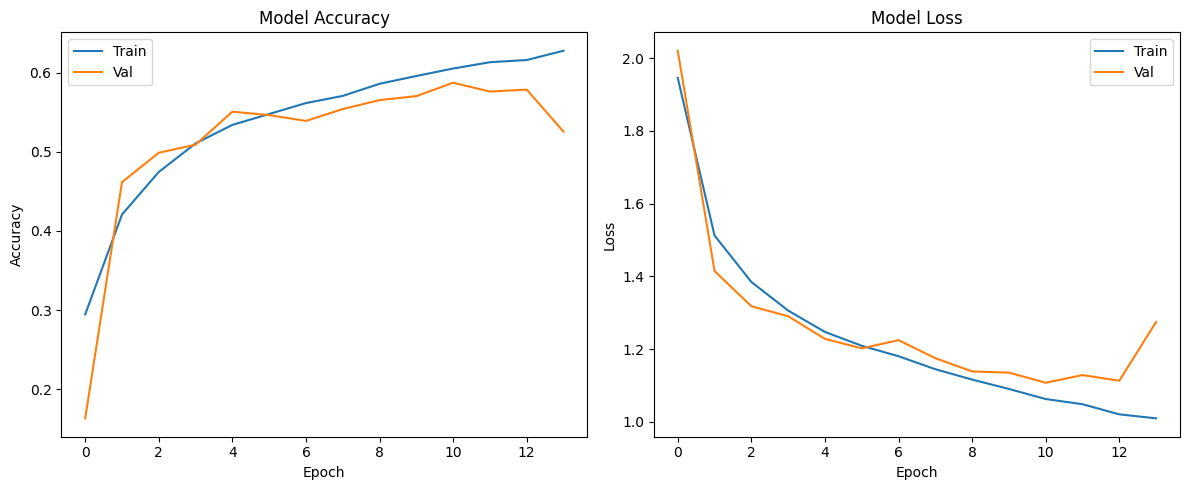

In [ ]:
optimizer = Adam(learning_rate=1e-4)

model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Callbacks
early_stop = EarlyStopping(patience=3, restore_best_weights=True, verbose=1, monitor = 'val_accuracy')
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
checkpoint = ModelCheckpoint('resnet50_best.keras', save_best_only=True, verbose=1)

history = model.fit(
    train_gen,
    epochs=100,
    validation_data=val_gen,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

test_loss, test_acc = model.evaluate(test_gen)
print(f"Test Accuracy: {test_acc:.4f}")

# Plot training history
def plot_history(history):
    plt.figure(figsize=(12, 5))  # Create a figure with two subplots

    # Accuracy subplot (left)
    plt.subplot(1, 2, 1)  # 1 row, 2 columns, position 1
    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Val')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss subplot (right)
    plt.subplot(1, 2, 2)  # 1 row, 2 columns, position 2
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Val')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()  # Prevent overlapping labels
    plt.show()

plot_history(history)

test_results = {
    "test_loss": float(test_loss),
    "test_accuracy": float(test_acc)
}

with open('test_results_resnet.json', 'w') as f:
    json.dump(test_results, f)

**Classification Report**

In [5]:
# Load saved model
model = load_model('models/resnet50_best.keras')

# Predict on test data
y_pred_probs = model.predict(test_gen)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_gen.classes

# Full classification report
target_names = list(test_gen.class_indices.keys())
print("\nDetailed Classification Report:")
print(classification_report(y_true, y_pred, target_names=target_names))

C:\Users\User\AppData\Roaming\Python\Python310\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


225/225 ━━━━━━━━━━━━━━━━━━━━ 147s 644ms/step

Detailed Classification Report:
              precision    recall  f1-score   support

       angry       0.56      0.53      0.54       958
     disgust       0.66      0.23      0.34       111
        fear       0.50      0.31      0.38      1024
       happy       0.83      0.84      0.84      1774
     neutral       0.48      0.71      0.57      1233
         sad       0.55      0.40      0.46      1247
    surprise       0.62      0.82      0.71       831

    accuracy                           0.61      7178
   macro avg       0.60      0.55      0.55      7178
weighted avg       0.61      0.61      0.60      7178



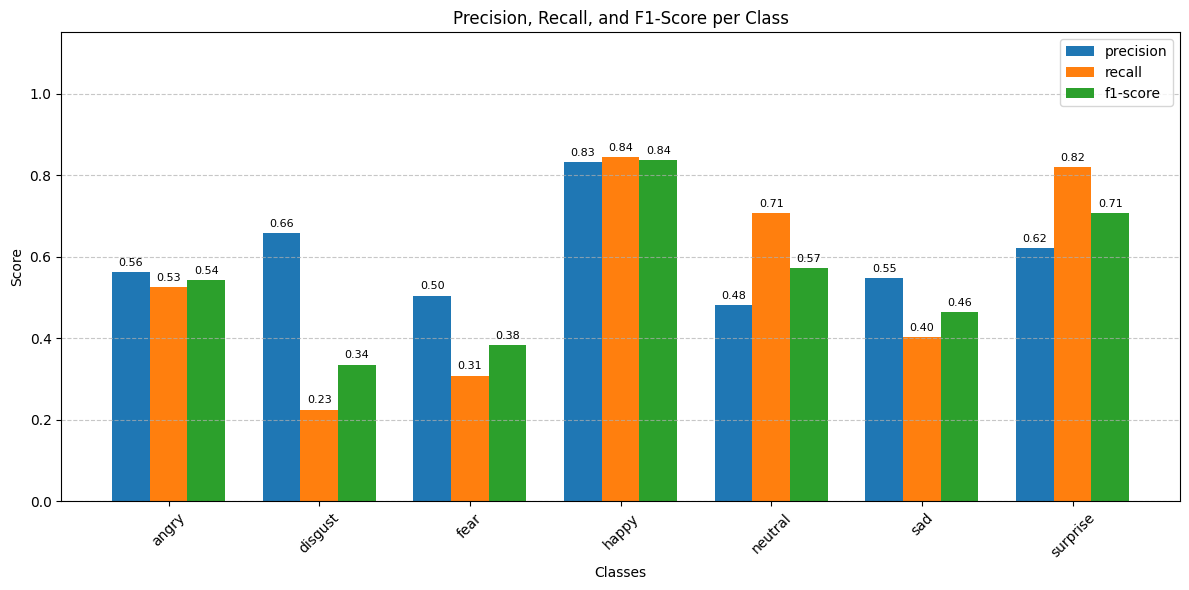

In [6]:
report_dict = classification_report(y_true, y_pred, target_names=target_names, output_dict=True)

df_report = pd.DataFrame(report_dict).transpose()
df_report = df_report.iloc[:-3]  # Remove 'accuracy', 'macro avg', 'weighted avg'
metrics = ['precision', 'recall', 'f1-score']
x = np.arange(len(df_report))  # class indices
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
for i, metric in enumerate(metrics):
    ax.bar(x + i * width, df_report[metric], width, label=metric)

# Add metric values above bars
for i, metric in enumerate(metrics):
    for j, val in enumerate(df_report[metric]):
        ax.text(j + i * width, val + 0.01, f"{val:.2f}", ha='center', va='bottom', fontsize=8)

# Formatting
ax.set_xlabel('Classes')
ax.set_ylabel('Score')
ax.set_title('Precision, Recall, and F1-Score per Class')
ax.set_xticks(x + width)
ax.set_xticklabels(df_report.index, rotation=45)
ax.set_ylim(0, 1.15)
ax.legend()
ax.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
metrics = ['precision', 'recall', 'f1-score']
x = np.arange(len(df_report))  # class indices
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
for i, metric in enumerate(metrics):
    ax.bar(x + i * width, df_report[metric], width, label=metric)

# Add metric values above bars
for i, metric in enumerate(metrics):
    for j, val in enumerate(df_report[metric]):
        ax.text(j + i * width, val + 0.01, f"{val:.2f}", ha='center', va='bottom', fontsize=8)

# Formatting
ax.set_xlabel('Classes')
ax.set_ylabel('Score')
ax.set_title('Precision, Recall, and F1-Score per Class')
ax.set_xticks(x + width)
ax.set_xticklabels(df_report.index, rotation=45)
ax.set_ylim(0, 1.15)
ax.legend()
ax.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Confusion Matrix**

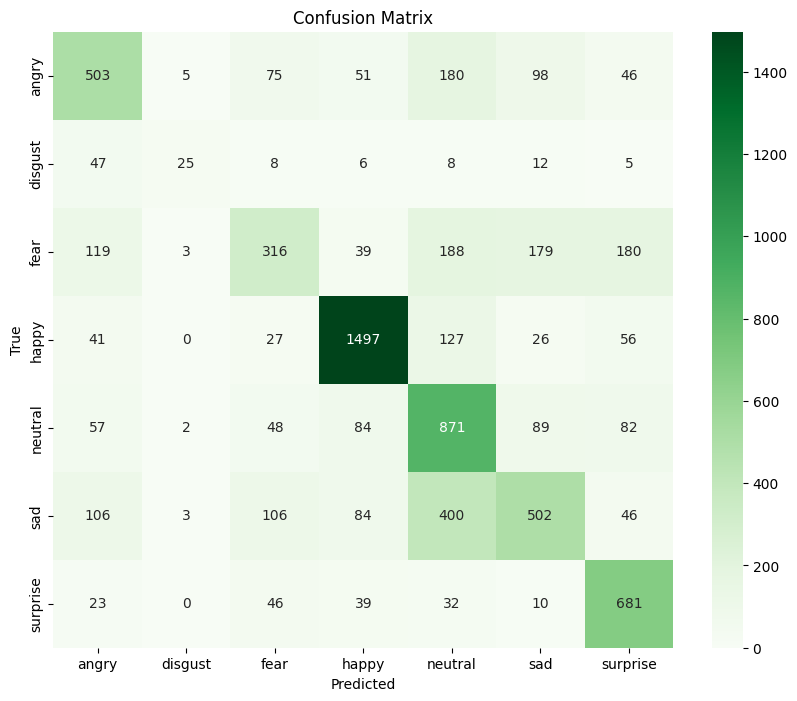

In [7]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

**ROC Curve**

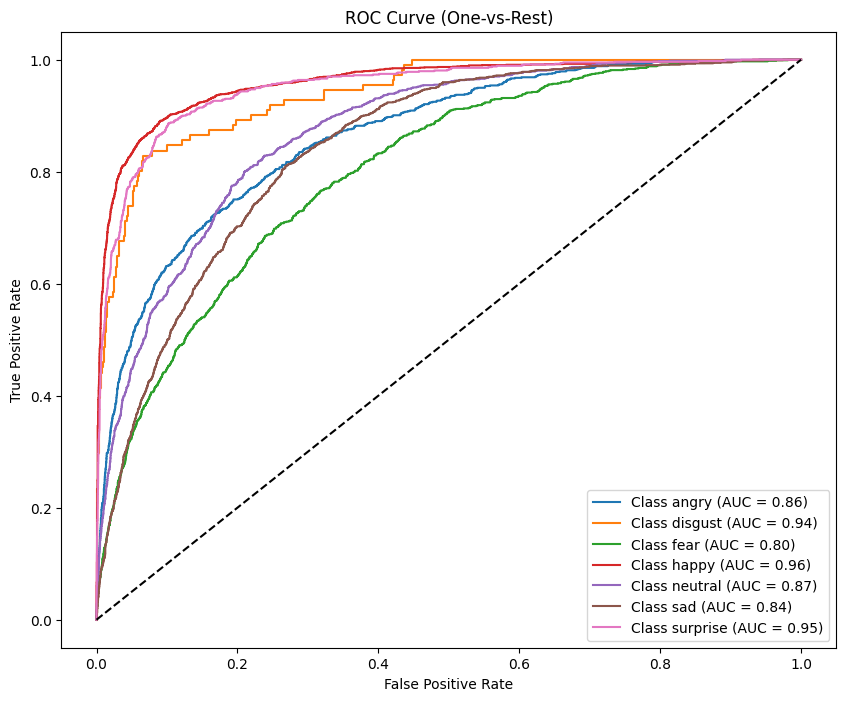

In [16]:
# Binarize the labels
n_classes = len(target_names)
y_true_bin = label_binarize(y_true, classes=list(range(n_classes)))

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(10, 8))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'Class {target_names[i]} (AUC = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (One-vs-Rest)')
plt.legend(loc='lower right')
plt.show()

**Grad-CAM**

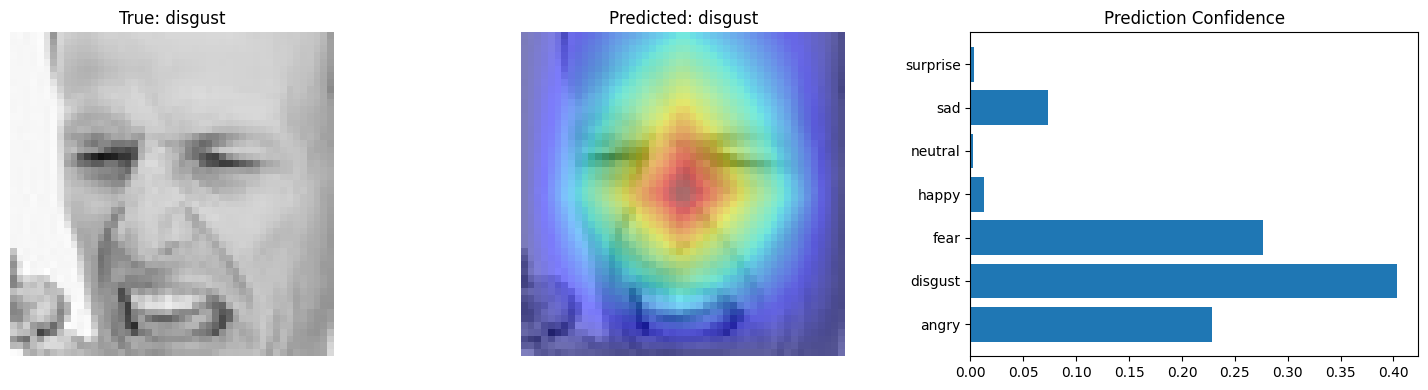

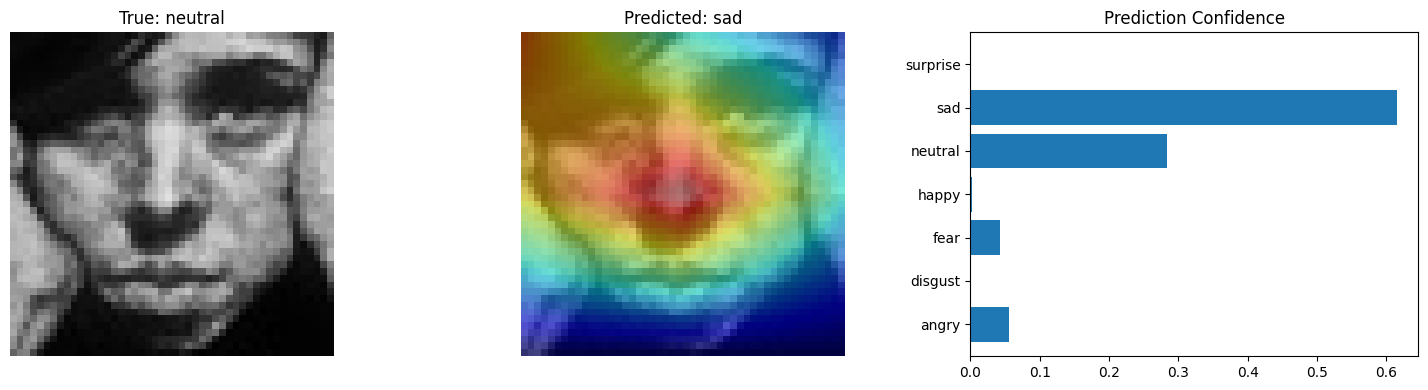

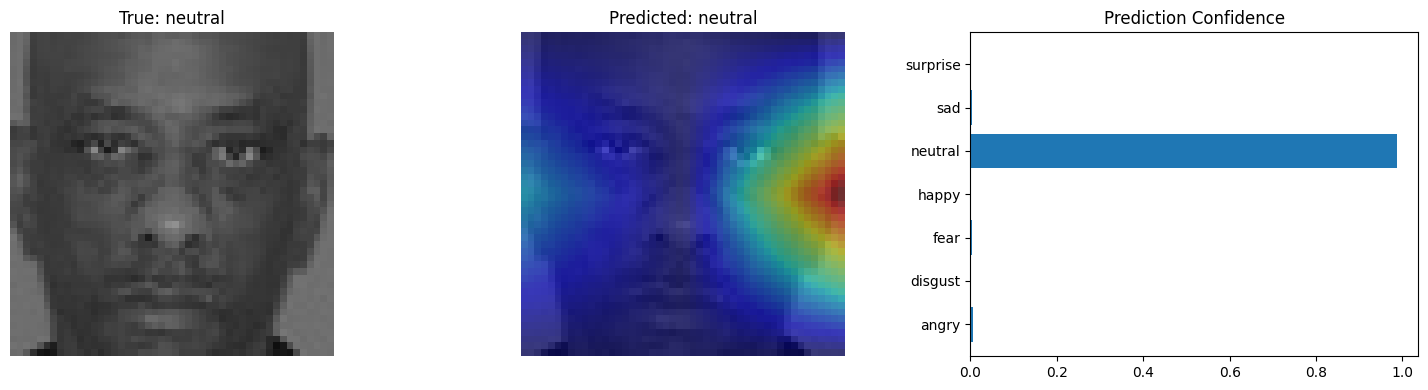

In [5]:
def load_random_image(test_dir, class_names, target_size=(48, 48)):
    emotion = choice(class_names)
    emotion_dir = os.path.join(test_dir, emotion)
    img_name = choice([f for f in os.listdir(emotion_dir) if f.endswith(('.jpg', '.png'))])
    img_path = os.path.join(emotion_dir, img_name)

    # Read, preprocess
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, target_size)
    img = img.astype('float32') / 255.0
    return np.expand_dims(img, axis=0), class_names.index(emotion), img_path

# Grad-CAM Visualization
def run_gradcam(model, test_dir, class_names, num_samples=3, penultimate_layer_idx='conv4_block6_out'):
    gradcam = Gradcam(model)
    
    for _ in range(num_samples):
        img, true_class, path = load_random_image(test_dir, class_names)
        score = CategoricalScore([np.argmax(model.predict(img, verbose=0)[0])])
        
        cam = gradcam(score, img, penultimate_layer=penultimate_layer_idx)
        cam = np.maximum(cam, 0)
        cam = cam / (cam.max() + 1e-8)
        
        # Plot original + CAM overlay + confidence
        pred_probs = model.predict(img, verbose=0)[0]
        pred_class = np.argmax(pred_probs)

        plt.figure(figsize=(15, 4))

        # Original
        plt.subplot(1, 3, 1)
        plt.imshow(img[0])
        plt.title(f"True: {class_names[true_class]}")
        plt.axis('off')

        # Grad-CAM heatmap overlay
        plt.subplot(1, 3, 2)
        plt.imshow(img[0])
        plt.imshow(cam[0], cmap='jet', alpha=0.5)
        plt.title(f"Predicted: {class_names[pred_class]}")
        plt.axis('off')

        # Prediction Confidence
        plt.subplot(1, 3, 3)
        plt.barh(class_names, pred_probs)
        plt.title("Prediction Confidence")
        plt.tight_layout()
        plt.show()

# Usage
run_gradcam(model, test_dir, class_names=target_names, num_samples=3)

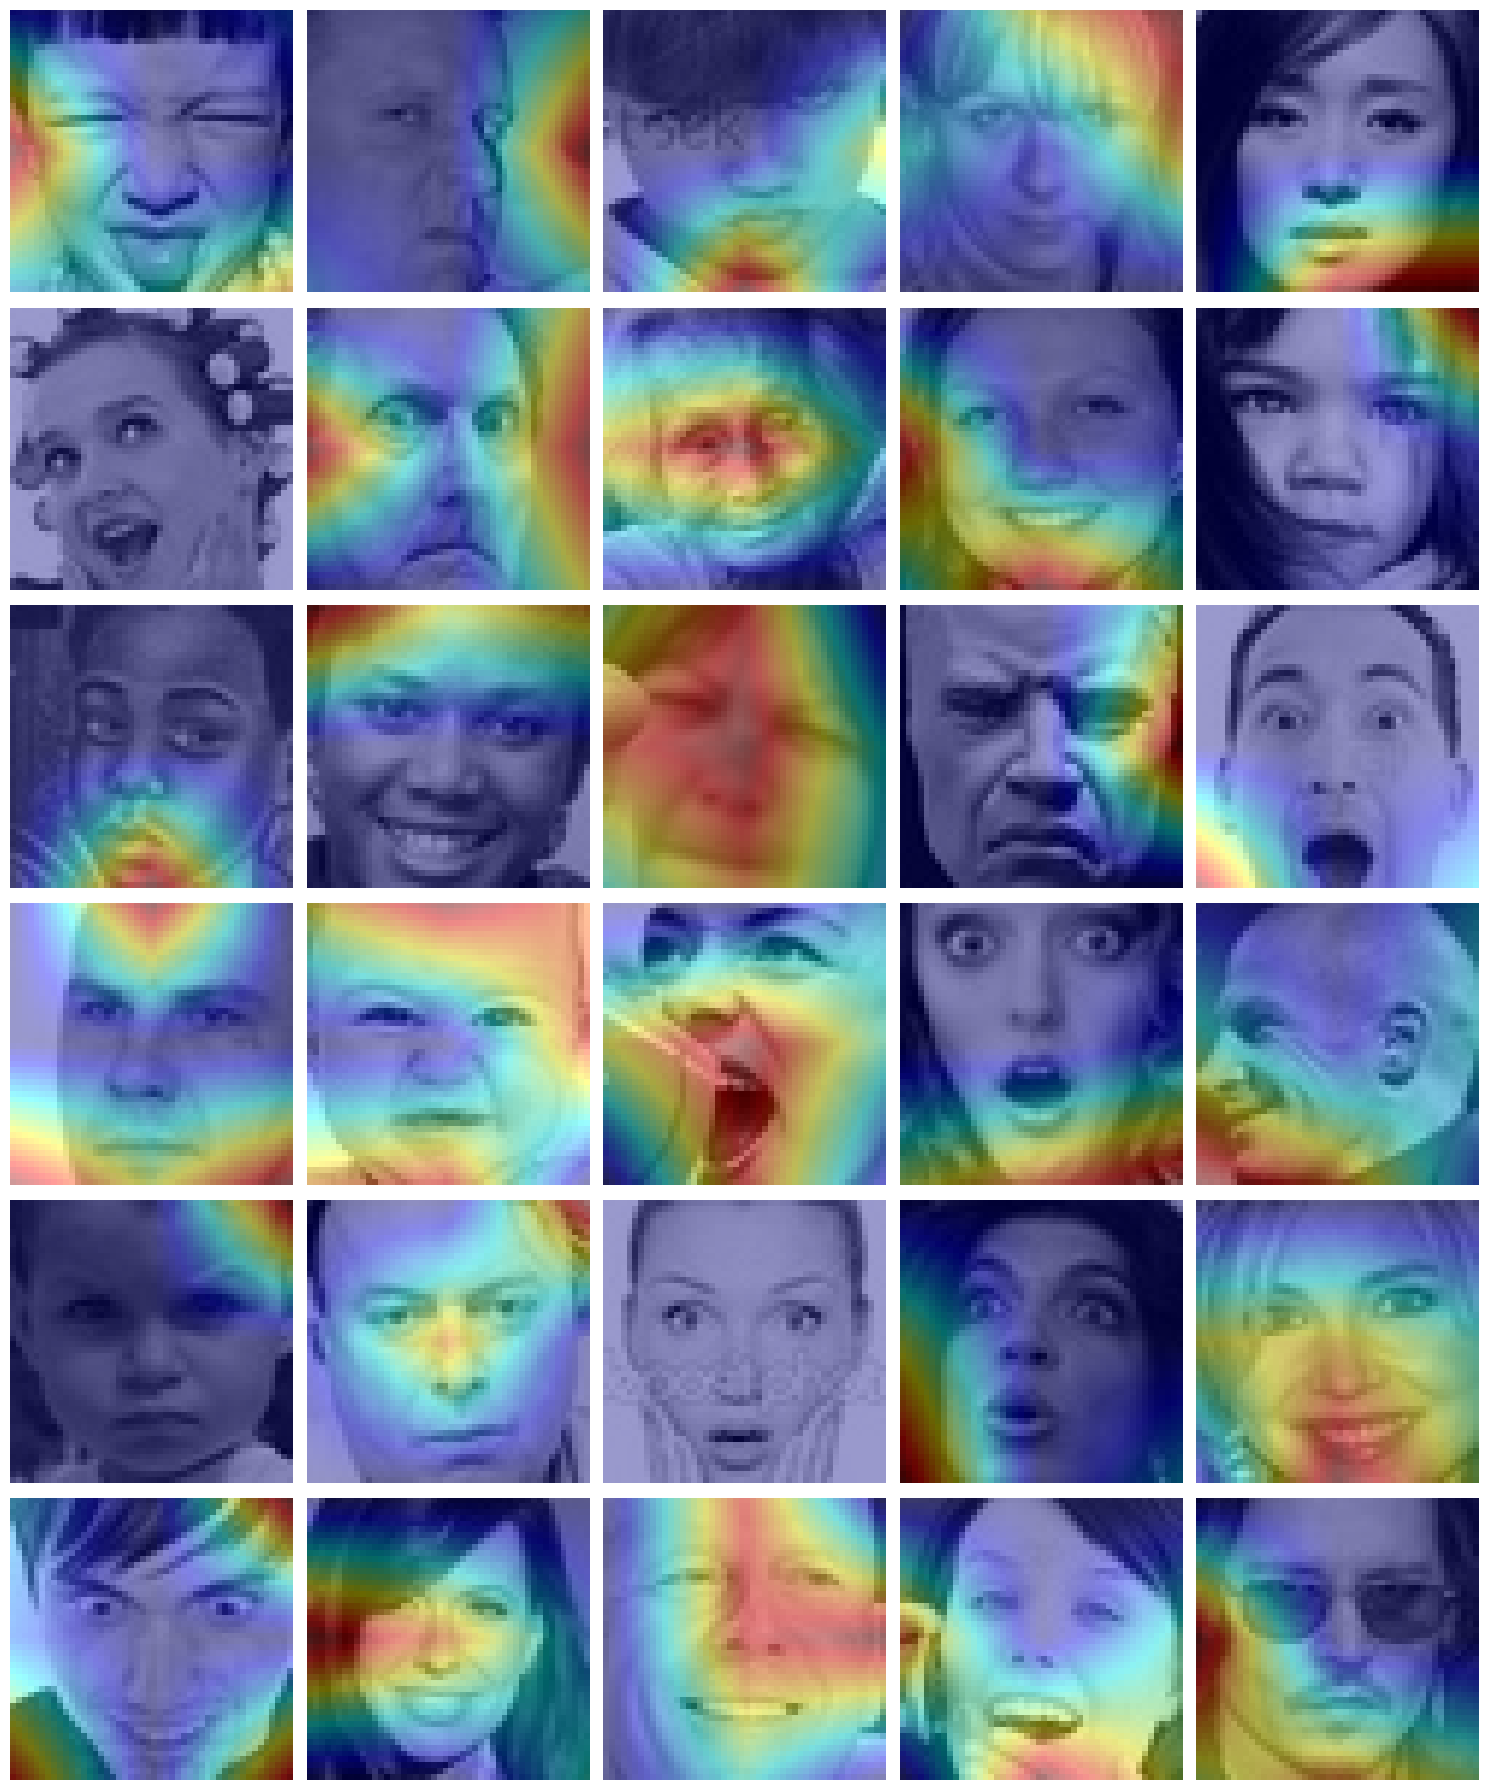

In [6]:
# Load and preprocess a random image from test_dir
def load_random_image(test_dir, class_names, target_size=(48, 48)):
    emotion = choice(class_names)
    emotion_dir = os.path.join(test_dir, emotion)
    img_name = choice([f for f in os.listdir(emotion_dir) if f.endswith(('.jpg', '.png'))])
    img_path = os.path.join(emotion_dir, img_name)

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, target_size)
    img = img.astype('float32') / 255.0
    return np.expand_dims(img, axis=0), class_names.index(emotion), img_path

# Grad-CAM visualization for multiple random images
def run_gradcam_grid(model, test_dir, class_names, num_images=30, penultimate_layer_idx='conv4_block6_out'):
    gradcam = Gradcam(model)

    n_cols = 5
    n_rows = int(np.ceil(num_images / n_cols))
    plt.figure(figsize=(n_cols * 3, n_rows * 3))

    for i in range(num_images):
        img, true_class, path = load_random_image(test_dir, class_names)
        pred = model.predict(img, verbose=0)[0]
        pred_class = np.argmax(pred)
        score = CategoricalScore([pred_class])

        cam = gradcam(score, img, penultimate_layer=penultimate_layer_idx)
        cam = np.maximum(cam, 0)
        cam = cam / (cam.max() + 1e-8)

        # Grad-CAM heatmap overlay only
        heatmap = cam[0]
        overlay = np.uint8(255 * heatmap)
        overlay = cv2.applyColorMap(overlay, cv2.COLORMAP_JET)
        overlay = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)

        img_rgb = np.uint8(255 * img[0])
        combined = cv2.addWeighted(img_rgb, 0.6, overlay, 0.4, 0)

        plt.subplot(n_rows, n_cols, i + 1)
        plt.imshow(combined)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Usage
run_gradcam_grid(model, test_dir, class_names=target_names, num_images=30)